In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules
from lfp_spike_window_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS


In [5]:
cell_num =27 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell 27  
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 27

## Step 0: Get loaded data 

In [6]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c27_lfp.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c27patch_filt.npy'


In [7]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

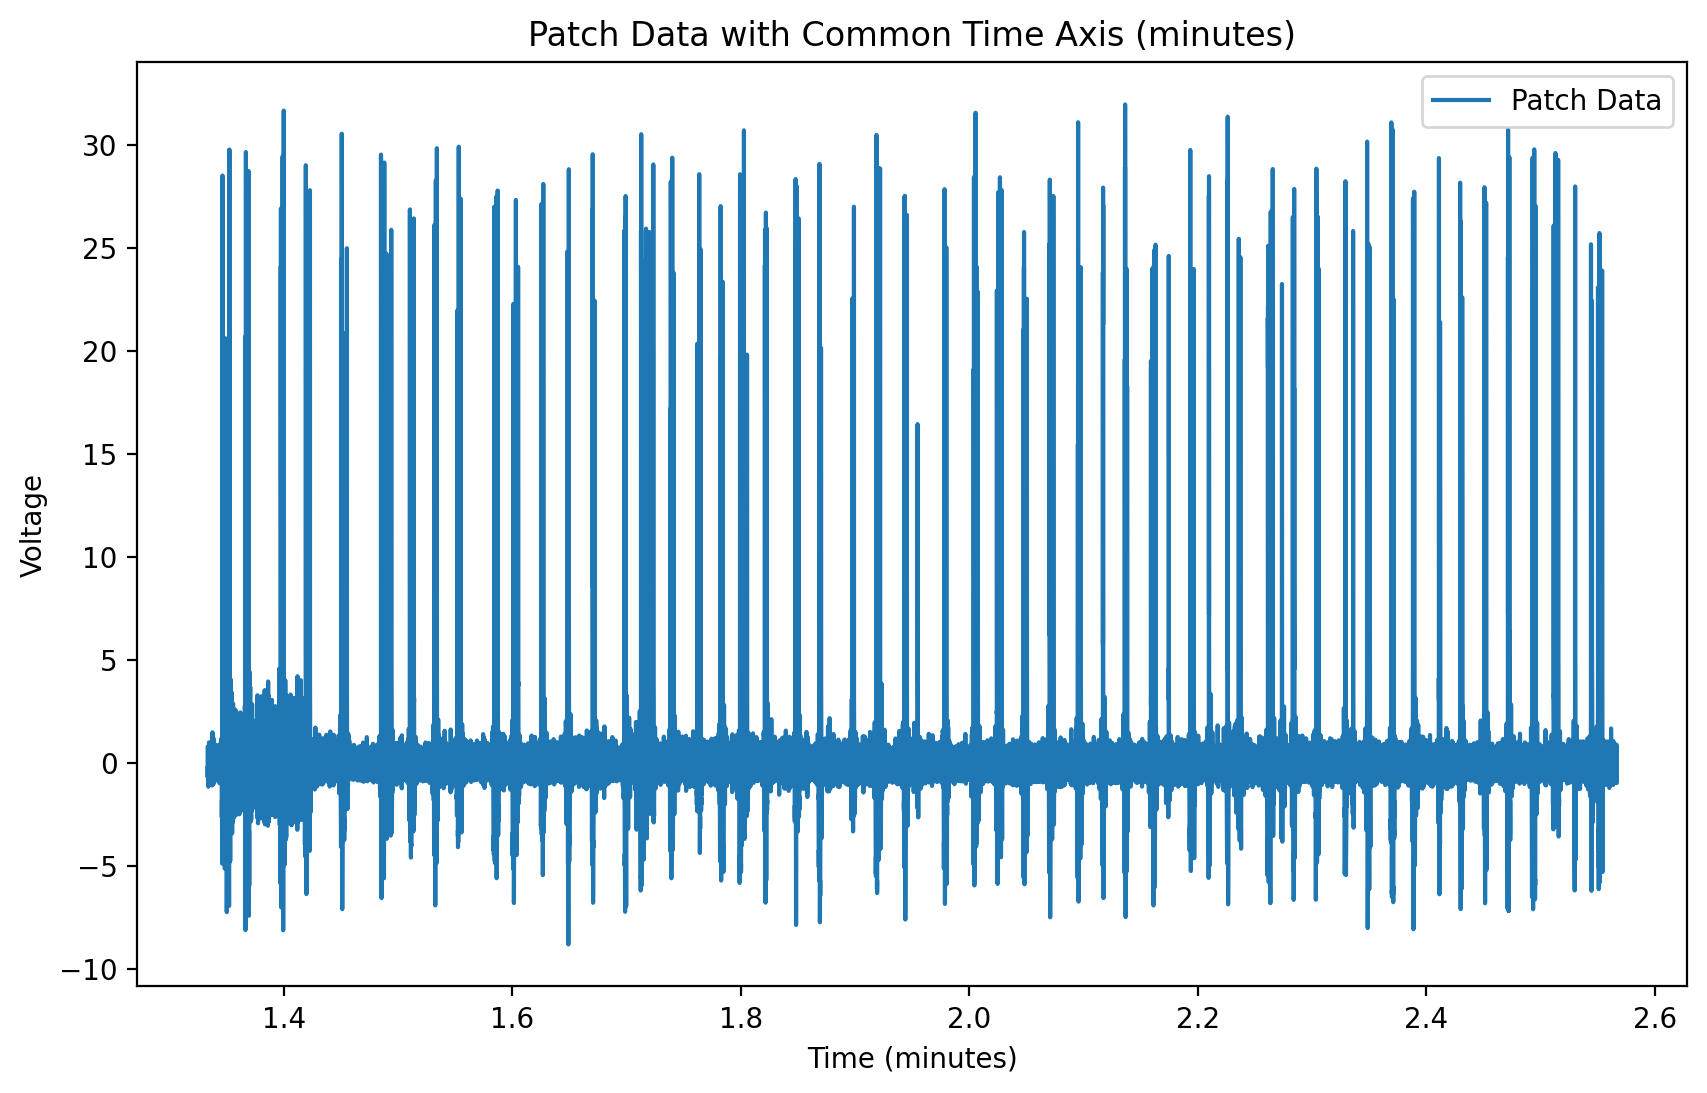

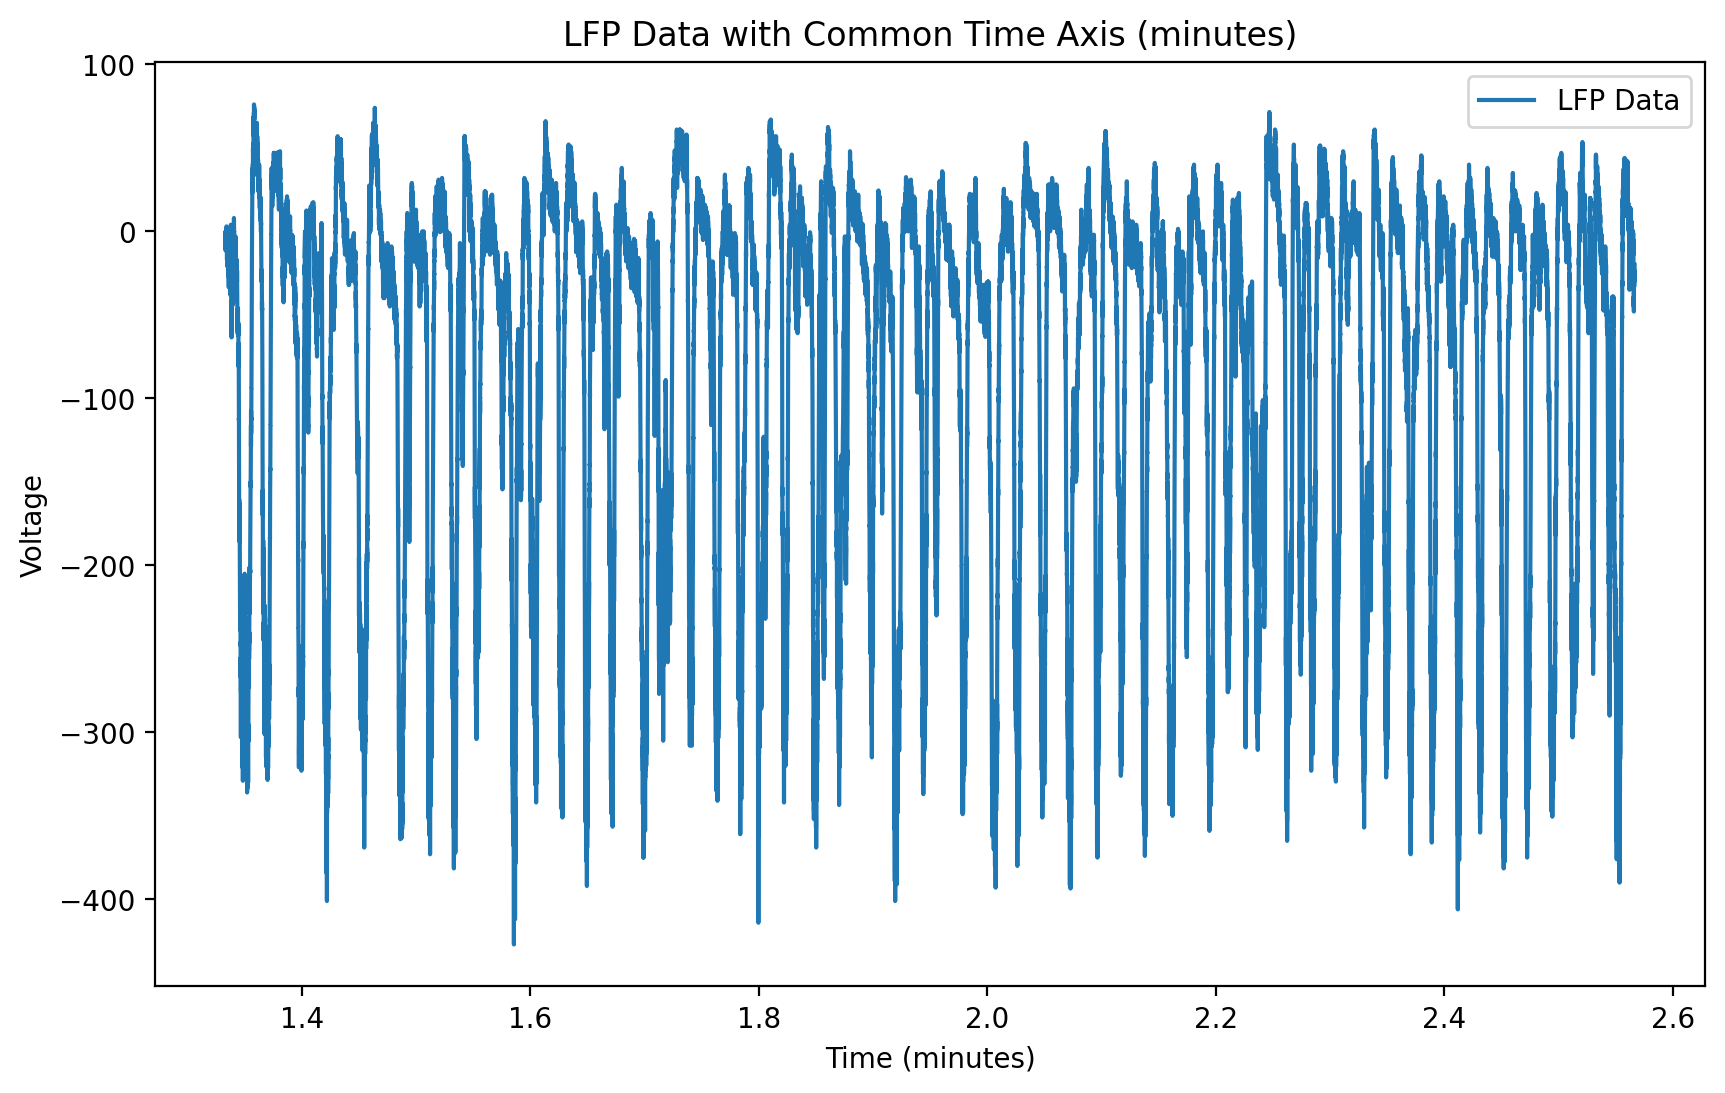

In [8]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 25.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: Detect and fit spikes from patch data

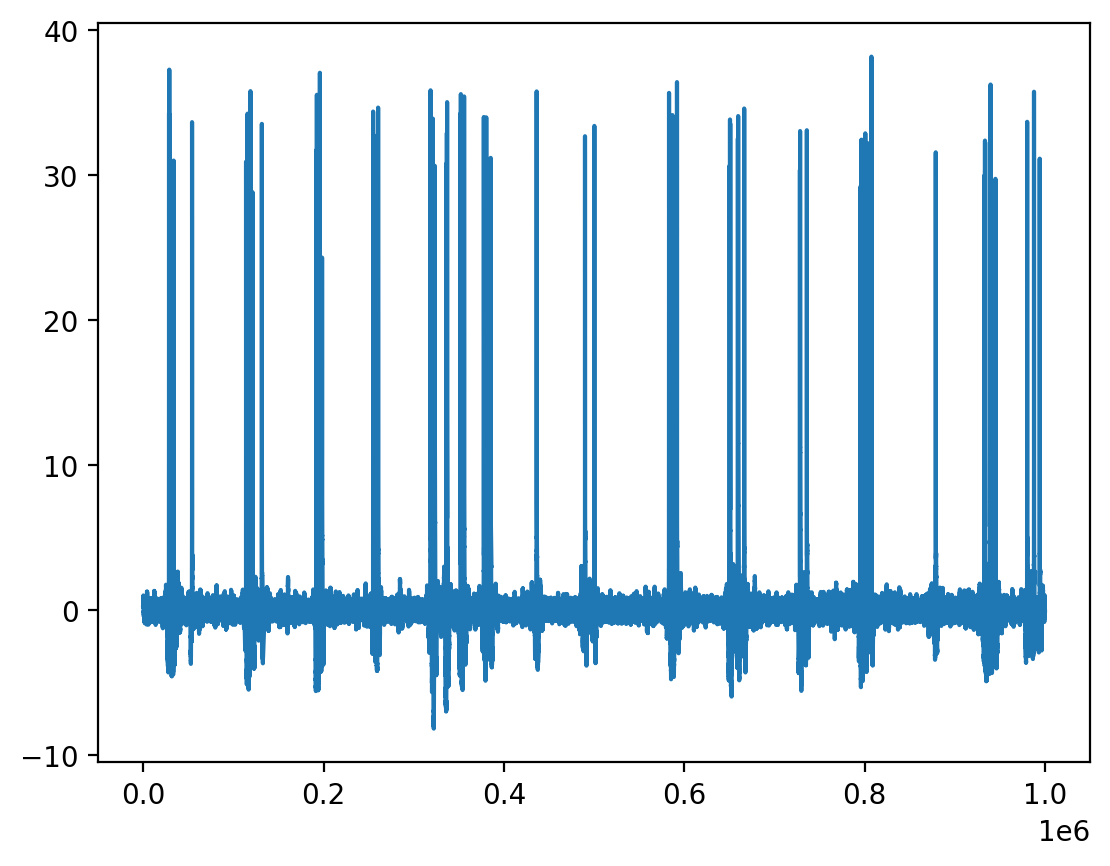

In [10]:
plt.plot(patch_filt[:1000000] )

In [11]:



#threshold in mVs
sp = Spike(thresh_amp=15, window_length=(5., 5.), smooth_frac=.01)

In [12]:

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm, flip_signal=False)

Spike:   0%|          | 0/1496 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


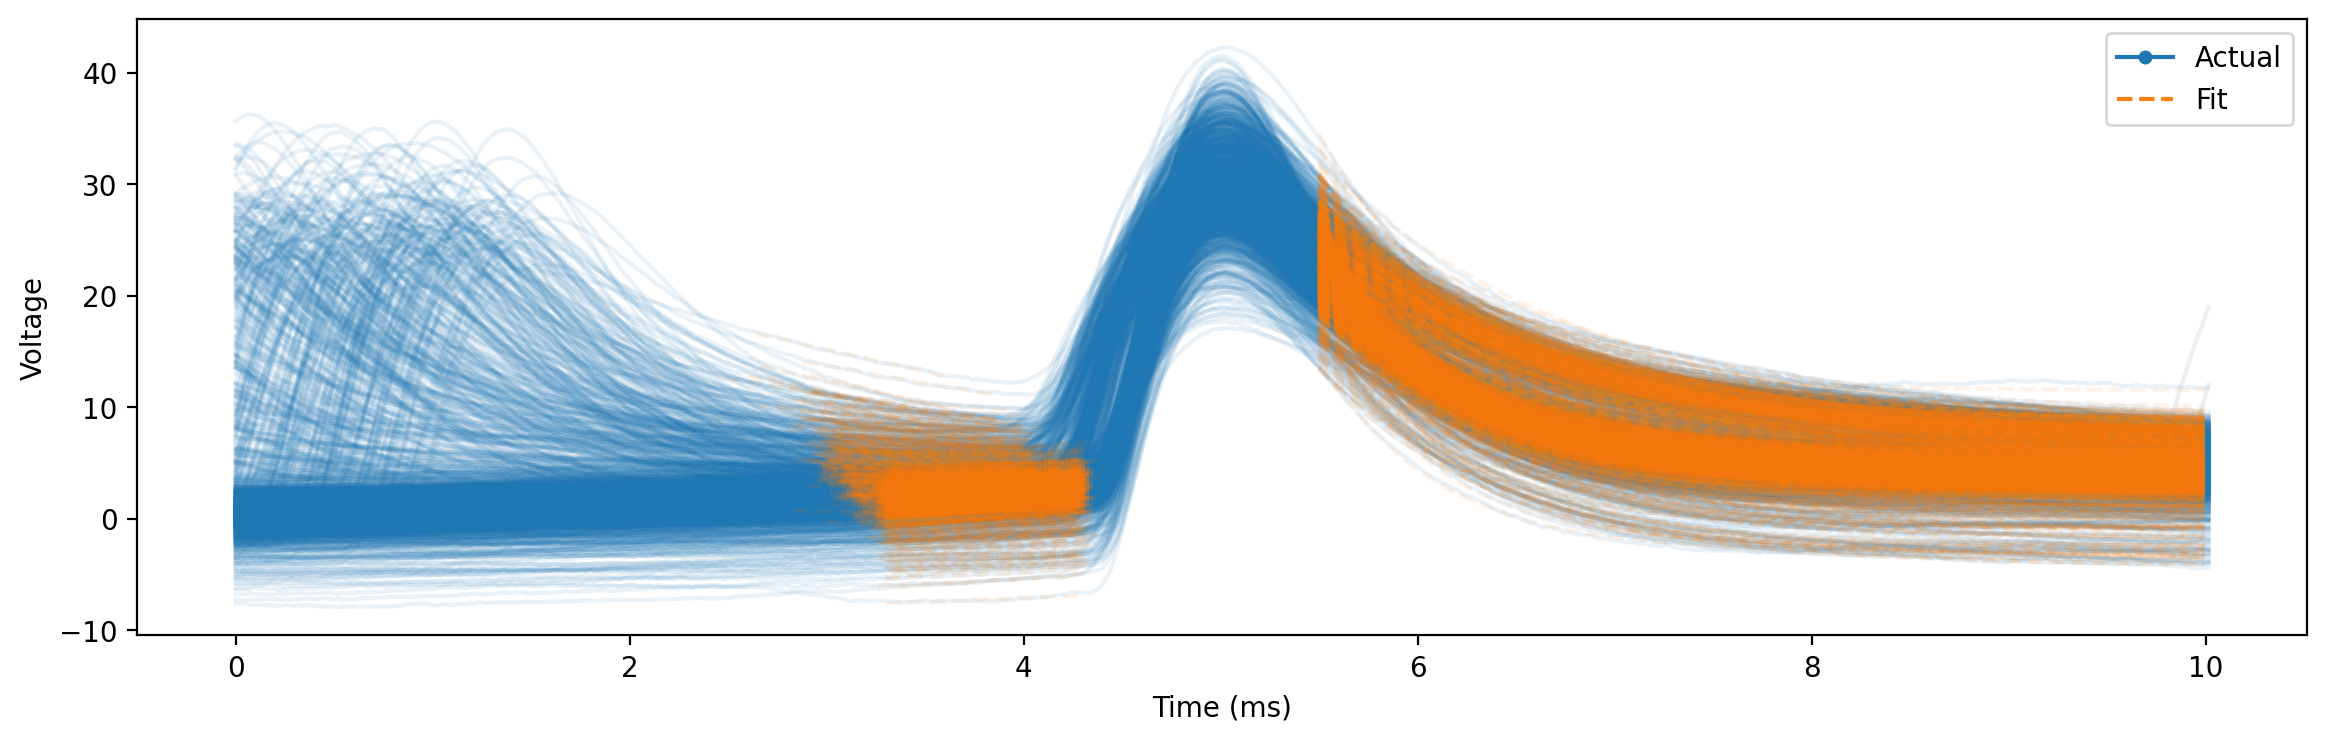

In [18]:
sp.plot()

### Filter spikes 

In [19]:
sp.filter_features()  # Applies default filters in-place

Filtering already applied. Create new instance with inplace=False to re-filter.


### Get spike dataframe (with spike times column)

In [15]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [16]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
0,0.831264,0.76,2.175625,37.159431,1.54,0.488185,1.060599,6.280598,1.822091,28974,579.203281,0
1,1.301123,0.68,2.432262,26.044590,1.28,0.565906,0.785925,1.198710,1.469320,32295,645.591564,1
3,1.208969,0.66,1.659889,33.597074,1.08,0.883541,1.675188,2.721035,3.078032,54213,1083.742234,2
4,0.901014,0.66,-1.549076,30.813059,1.12,0.899997,1.446296,-0.961640,1.517516,114083,2280.570440,3
6,0.848046,0.66,3.066991,35.618422,1.08,0.978739,1.788263,4.431164,1.679039,118955,2377.963910,4
...,...,...,...,...,...,...,...,...,...,...,...,...
1491,1.045474,0.66,4.731849,38.264729,1.08,0.899013,1.643298,6.161639,1.922207,40394322,807500.650423,1405
1492,0.867023,0.72,3.797083,32.244505,1.14,0.731312,1.293713,3.493535,3.164163,40398504,807584.250482,1406
1493,0.927436,0.74,3.426125,25.883916,1.48,0.471966,0.963138,5.629404,1.815370,40471507,809043.613260,1407
1494,0.579992,0.64,4.471907,36.945890,1.06,0.991244,1.668280,4.414232,1.683380,40474777,809108.982030,1408


### Get spike times


In [17]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

## STEP 2: Cluster ISI spike groups 

In [26]:
from sklearn.mixture import GaussianMixture


def cluster_isi_gmm(df, column='log_isi', plot=True, random_state=0):
    """
    Fit 2-comp GMM on df[column], add 'isi_cluster' = {'short_ISI','long_ISI', np.nan}.
    Leaves rows with NaN in `column` as NaN (e.g., the final spike with no ISI).
    Returns (df_out, boundary_x).
    """
    if column not in df.columns:
        raise KeyError(f"Column '{column}' not found.")
    df_out = df.copy()

    x = pd.to_numeric(df_out[column], errors='coerce')
    valid_mask = x.notna() & np.isfinite(x)

    # Fit on valid rows only
    X = x[valid_mask].to_numpy().reshape(-1, 1)
    if X.shape[0] < 2:
        df_out['isi_cluster'] = np.nan
        return df_out, np.nan

    gmm = GaussianMixture(n_components=2, random_state=random_state)
    gmm.fit(X)
    labels = gmm.predict(X)

    means = gmm.means_.ravel()
    short_idx = int(np.argmin(means))
    long_idx  = int(np.argmax(means))

    mapped = np.where(labels == short_idx, 'short_ISI', 'long_ISI')

    # Initialize column with NaN; fill only valid rows
    df_out['isi_cluster'] = np.nan
    df_out.loc[valid_mask, 'isi_cluster'] = mapped

    # Analytic boundary (Gaussian intersection)
    m1, m2 = gmm.means_.ravel()
    v1, v2 = gmm.covariances_.ravel()
    w1, w2 = gmm.weights_.ravel()

    # Solve w1 N(x|m1,v1) = w2 N(x|m2,v2)
    a = (1/(2*v2)) - (1/(2*v1))
    b = (m1/v1) - (m2/v2)
    c = (m2**2/(2*v2)) - (m1**2/(2*v1)) + np.log((w2*np.sqrt(v1)) / (w1*np.sqrt(v2)))
    if np.isclose(a, 0):
        boundary_x = -c/b if not np.isclose(b, 0) else np.nan
    else:
        disc = b*b - 4*a*c
        if disc < 0:
            boundary_x = np.nan
        else:
            r1 = (-b + np.sqrt(disc)) / (2*a)
            r2 = (-b - np.sqrt(disc)) / (2*a)
            lo, hi = (min(m1, m2), max(m1, m2))
            # prefer root between means
            candidates = [r for r in (r1, r2) if lo <= r <= hi]
            if candidates:
                mid = 0.5*(lo+hi)
                boundary_x = min(candidates, key=lambda r: abs(r-mid))
            else:
                boundary_x = r1 if abs(r1-mid) < abs(r2-mid) else r2

    if plot:
        plt.figure(figsize=(7,4))
        plt.hist(X.ravel(), bins=40)
        if np.isfinite(boundary_x):
            plt.axvline(boundary_x, linestyle='--', linewidth=2, label=f'Boundary = {boundary_x:.2f}')
            plt.legend()
        plt.title('ISI clustering (GMM)')
        plt.xlabel(column)
        plt.tight_layout()
        plt.show()

    return df_out, float(boundary_x) if np.isfinite(boundary_x) else np.nan


In [28]:
df_features_clustered, isi_boundary = cluster_isi_gmm(df_features, column='log_isi', plot=True)
df_features_clustered.tail(3)  # you'll see the last row has isi_cluster = NaN
print("Boundary (log_isi):", isi_boundary)


AttributeError: 'NoneType' object has no attribute 'split'

#### Cluster spikes into groups based on ISIs 

Text(0, 0.5, 'aperiodic exponent')

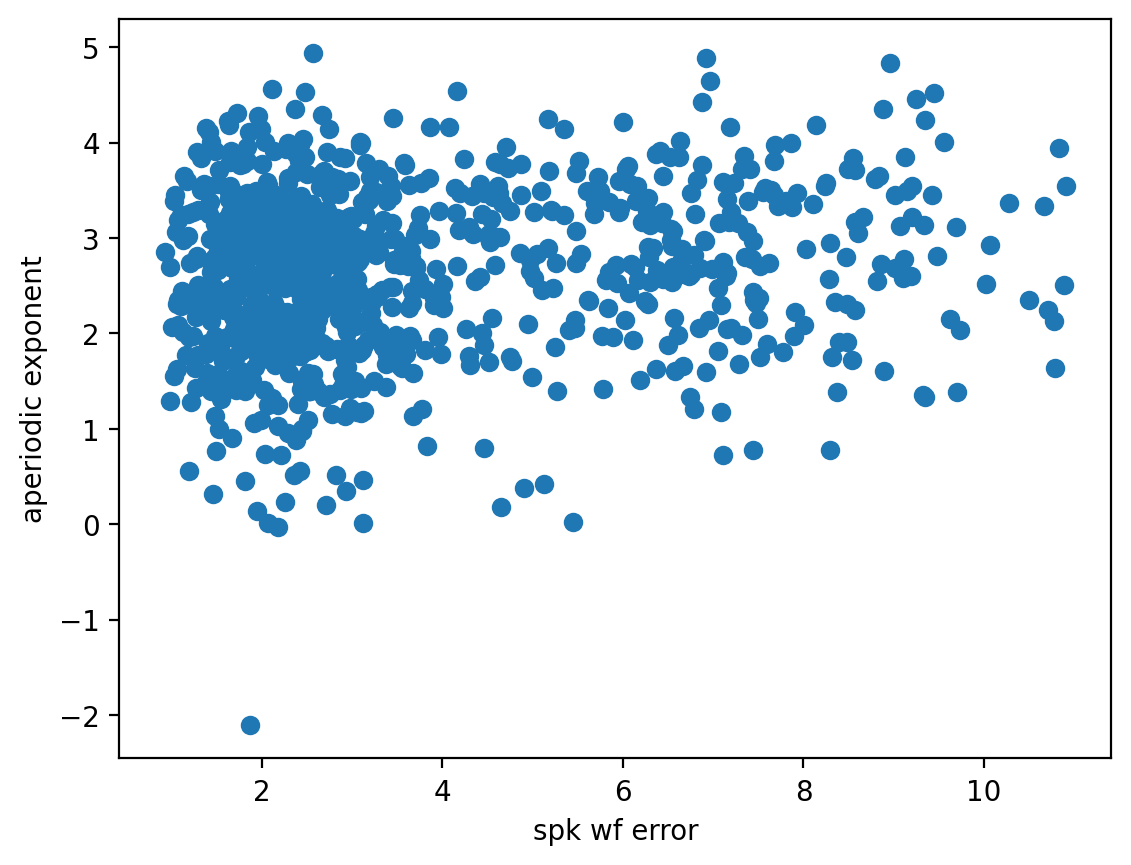

In [31]:
plt.scatter(spike_lfp_df['wf_error'], spike_lfp_df['aperiodic_exponent'])
plt.xlabel("spk wf error")
plt.ylabel("aperiodic exponent")

Text(0, 0.5, 'exp const')

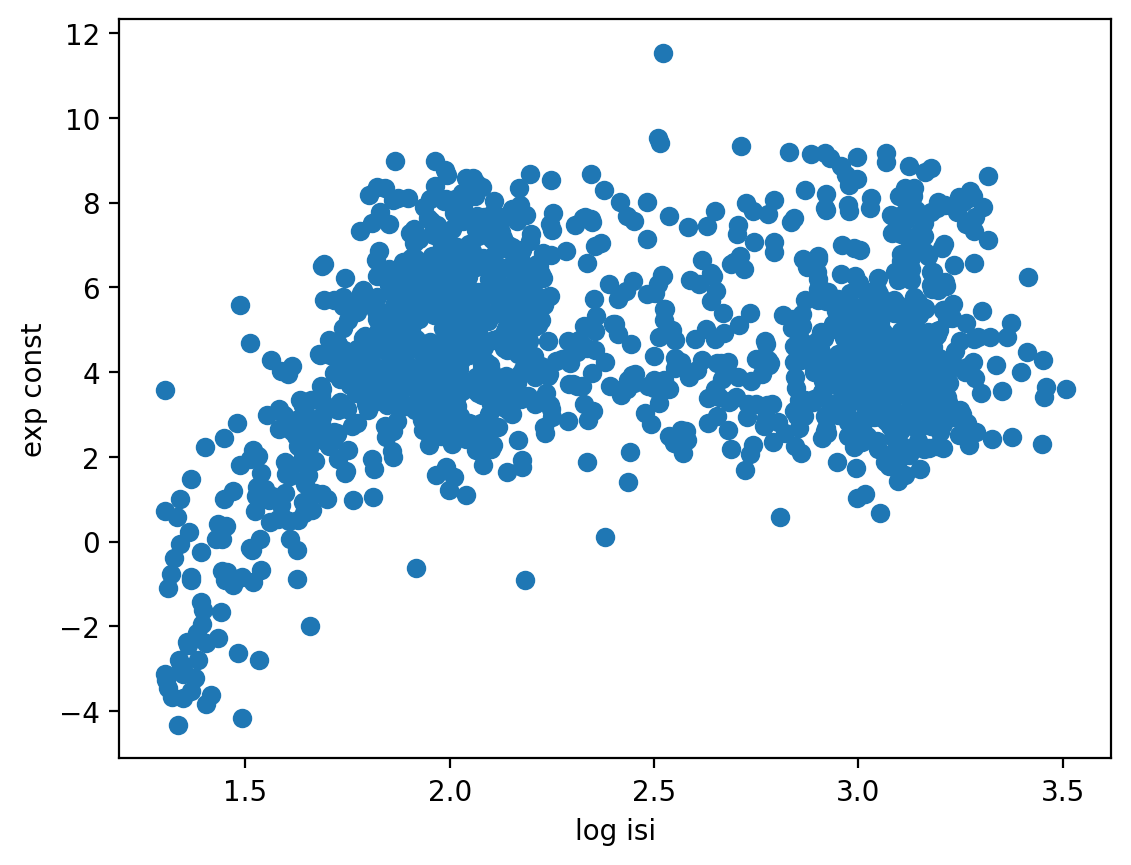

In [42]:
plt.scatter(spike_lfp_with_feats['log_isi'],spike_lfp_with_feats['exp_const'])
plt.xlabel("log isi")
plt.ylabel("exp const")

Text(0, 0.5, 'peak width')

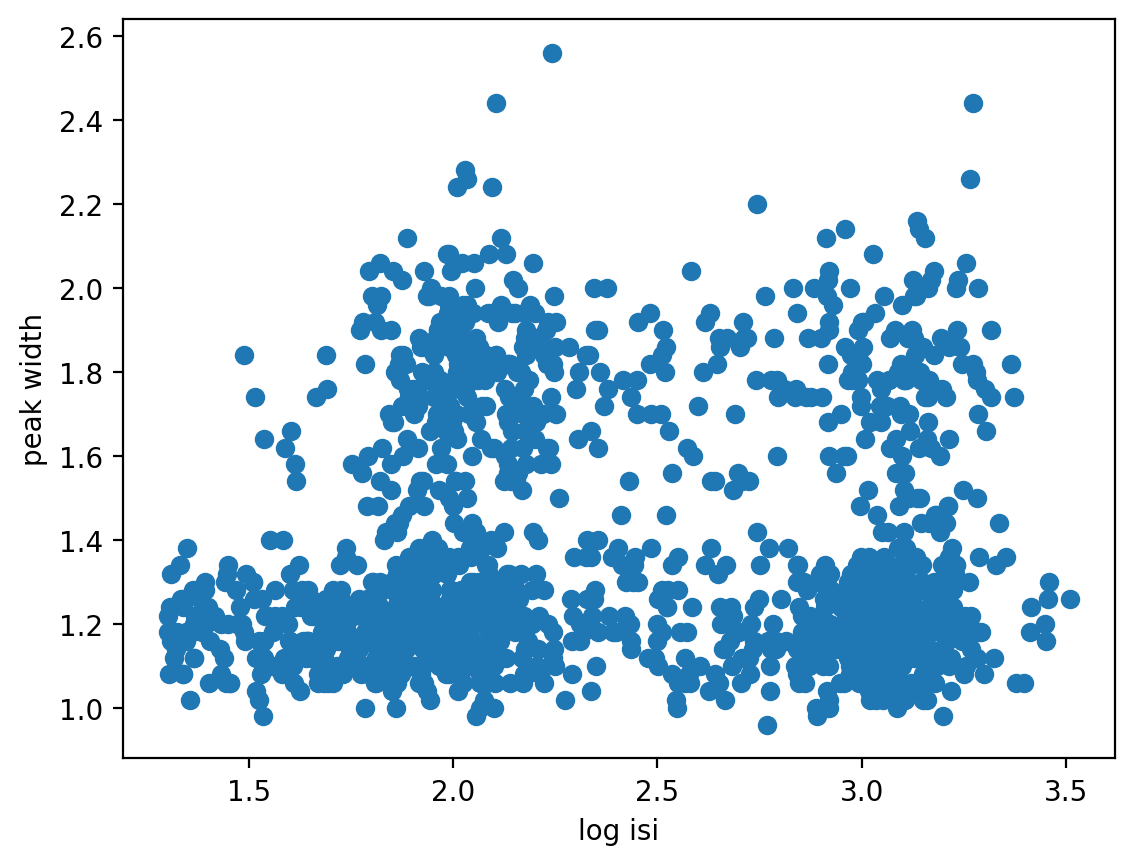

In [44]:
plt.scatter(spike_lfp_with_feats['log_isi'],spike_lfp_with_feats['peak_width'])
plt.xlabel("log isi")
plt.ylabel("peak width")

Text(0, 0.5, 'inflection time')

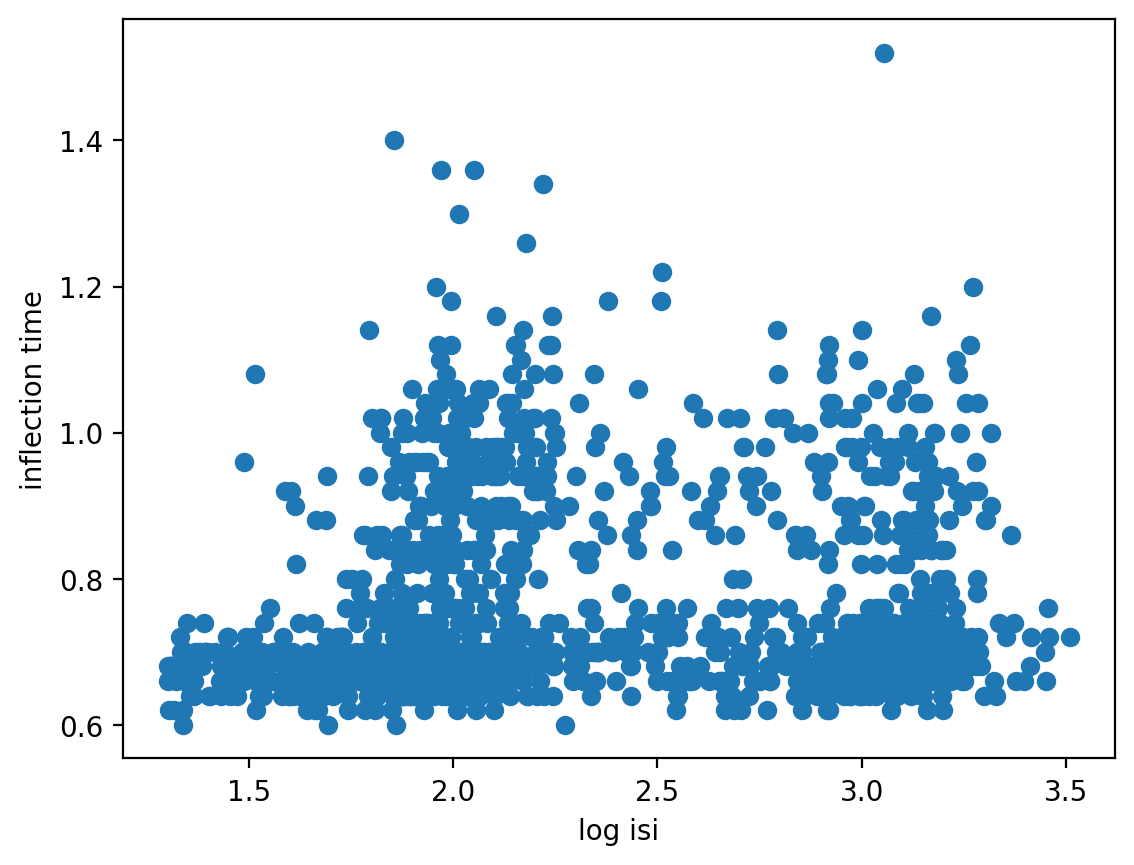

In [45]:
plt.scatter(spike_lfp_with_feats['log_isi'],spike_lfp_with_feats['inflection_time'])
plt.xlabel("log isi")
plt.ylabel("inflection time")

Text(0, 0.5, 'inflection time')

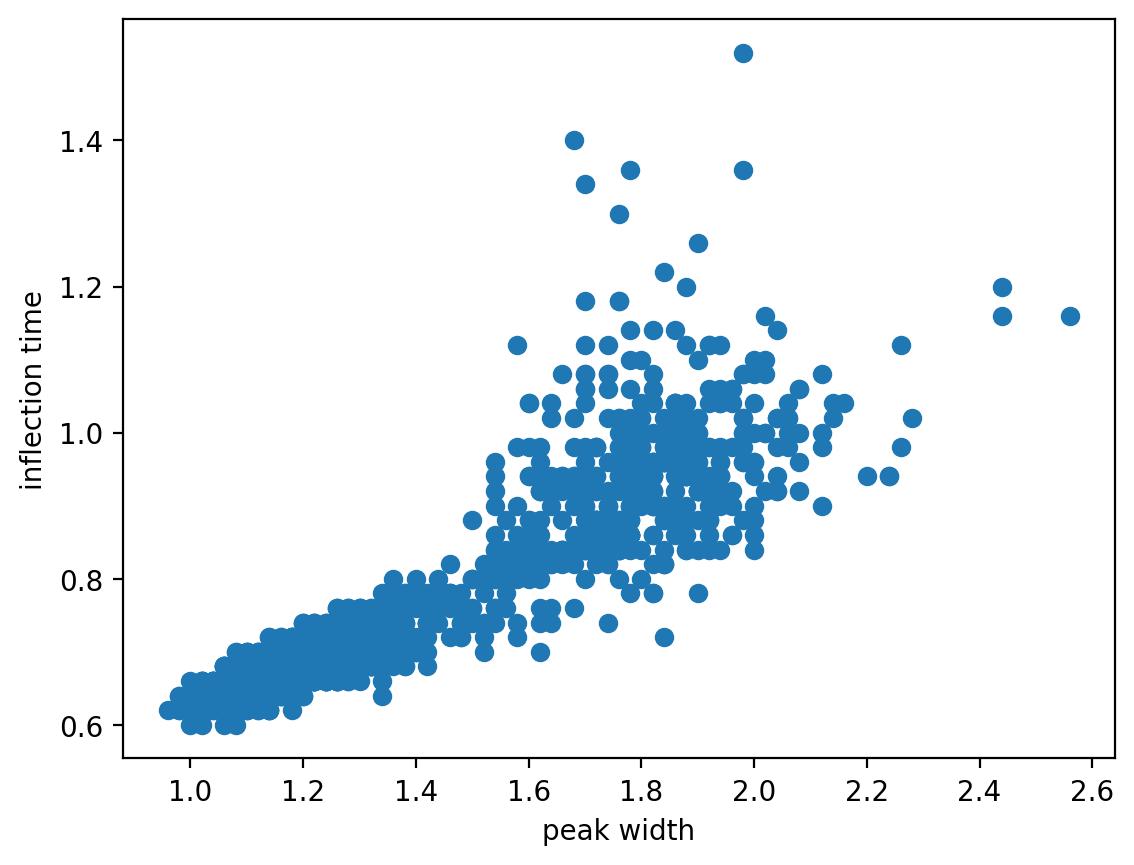

In [46]:
plt.scatter(spike_lfp_with_feats['peak_width'],spike_lfp_with_feats['inflection_time'])
plt.xlabel("peak width")
plt.ylabel("inflection time")